# **Customer Churn Prediction – SyriaTel**

### **Background**

Customer churn refers to the loss of customers when they stop using a company's services. In the telecommunications industry, churn is a critical issue due to the highly competitive market and the relatively low switching costs for customers. When customers leave, companies not only lose recurring revenue but also incur additional costs associated with acquiring new customers to replace them.

Research and industry trends consistently show that retaining existing customers is significantly more cost-effective than acquiring new ones. Therefore, understanding and predicting customer churn is essential for maintaining long-term profitability and customer loyalty.

---

### **Business Problem**

SyriaTel is facing challenges with customer retention, as a portion of its customer base discontinues its services over time. Currently, the company may only react after customers have already churned, which limits its ability to recover lost revenue.

The key business problem is the lack of a proactive system to identify customers who are at risk of churning before they actually leave. Without this capability, SyriaTel cannot efficiently target retention efforts or allocate resources effectively.

This project aims to address this gap by developing a predictive model that can classify customers as likely to churn or not. By identifying high-risk customers in advance, the company can implement targeted interventions such as promotional offers, improved customer service, or personalized engagement strategies to reduce churn rates.

---

### **Stakeholders**

This project is relevant to several key stakeholders within SyriaTel:

- **Customer Retention Team**  
  This team is directly responsible for reducing churn. They can use the model's predictions to identify at-risk customers and take immediate action, such as offering incentives or resolving service issues.

- **Marketing Team**  
  The marketing team can use churn predictions to design targeted campaigns aimed at retaining high-risk customers. This allows for more efficient use of marketing resources and improves campaign effectiveness.

- **Business Strategy Team**  
  This team focuses on long-term planning and decision-making. Insights from the model, such as key drivers of churn, can inform strategic initiatives, product improvements, and policy changes to enhance customer satisfaction and retention.

---

### **Objective**

The primary objective of this project is to build a classification model that predicts whether a customer is likely to churn. The model will use historical customer data to identify patterns and factors associated with churn behavior.

In addition to prediction, the project also aims to uncover the most important features influencing churn. These insights will help SyriaTel better understand customer behavior and guide data-driven decision-making.

---

### **Why This Matters**

Reducing customer churn has significant business impact:

- **Increase Revenue**  
  Retaining customers ensures a steady stream of recurring revenue and reduces losses associated with customer departure.

- **Improve Customer Satisfaction**  
  By identifying and addressing issues early, the company can enhance the overall customer experience.

- **Reduce Marketing Costs**  
  Targeted retention strategies are more cost-effective than broad customer acquisition campaigns.

- **Enable Proactive Decision-Making**  
  Predictive insights allow the company to act before churn occurs, rather than reacting after the fact.

Ultimately, leveraging machine learning to predict churn enables SyriaTel to move from reactive to proactive customer management, improving both operational efficiency and business outcomes.

---

## **Data Understanding**

In [59]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For cleaner plots
sns.set(style="whitegrid")

In [60]:
# Load the dataset

churn_df = pd.read_csv("C:\\Users\\Admin\\Data_Science\\PHASE3\\customer-churn-prediction-phase3-project\\data\\SyriaTel_Customer_Churn.csv")
churn_df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [61]:
# Checking the information of the dataset to understand the data types and missing values

churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

#### **Insights**
The dataset contains **3,333 observations** and **21 features**. It includes a mix of numerical `int64`, `float64` and categorical `object` variables.

The target variable, **`churn`**, is a boolean, confirming this is a **binary classification problem**.

There are **no missing values** in the dataset, which simplifies the data preparation process.

Some variables, such as `phone number`, are likely not useful for prediction since they act as unique identifiers.

---

In [62]:
# Drop the 'phone number' column as it is not useful for analysis
churn_df.drop(columns=['phone number'], inplace=True)

# Convert 'churn' column from boolean to binary (1 for churned, 0 for not churned)
churn_df['churn'] = churn_df['churn'].astype(int)

churn_df.head()

,state,account length,area code,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


## **Exploratory Data Analysis (EDA)**

### **Target Variable Distribution**

0    2850
1     483
Name: churn, dtype: int64


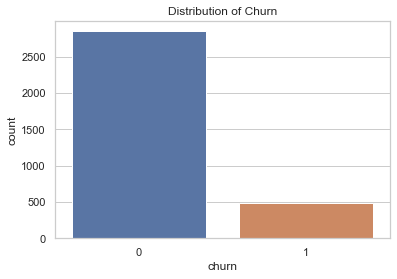

In [63]:
# Distribution of the target variable 'churn'
print(churn_df['churn'].value_counts())

sns.countplot(x='churn', data=churn_df)
plt.title('Distribution of Churn')
plt.show()

#### **Insights**
From the above output, there is class imbalance in the target variable **churn**.

**Class 0** represents customers who did **not churn** and it is the **majority class** with 2850 customers.

**Class 1** represents customers who **churn** and it is the **minority class** with 483 customers.

This class imbalance could affect the model, in that for most times it will predict the majority class.

---

### **Explore Numerical Features**

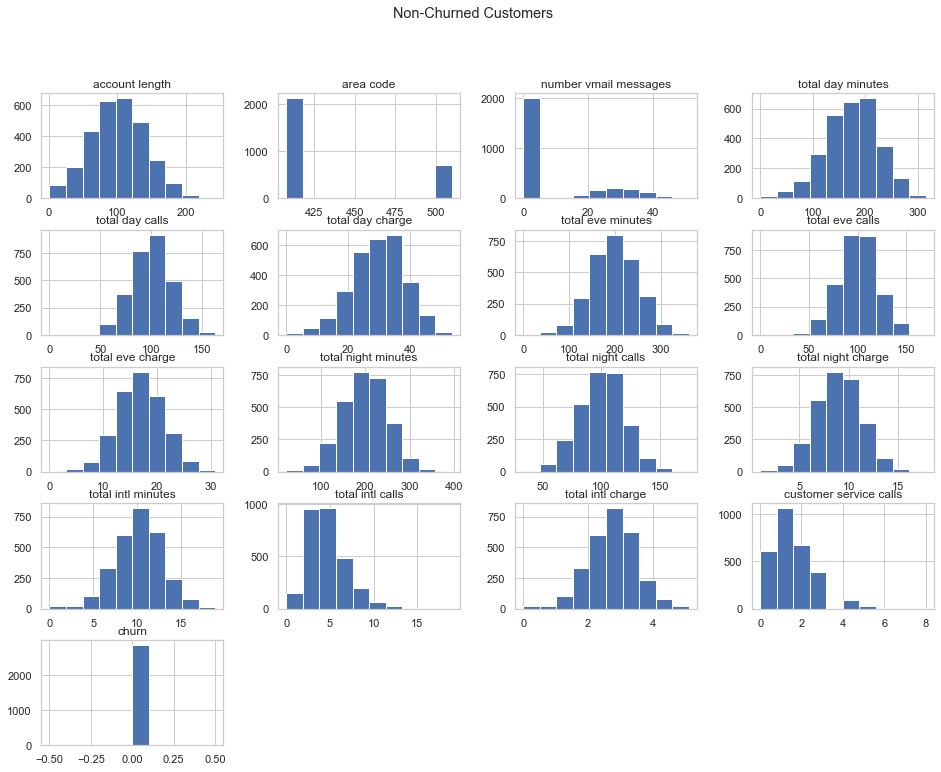

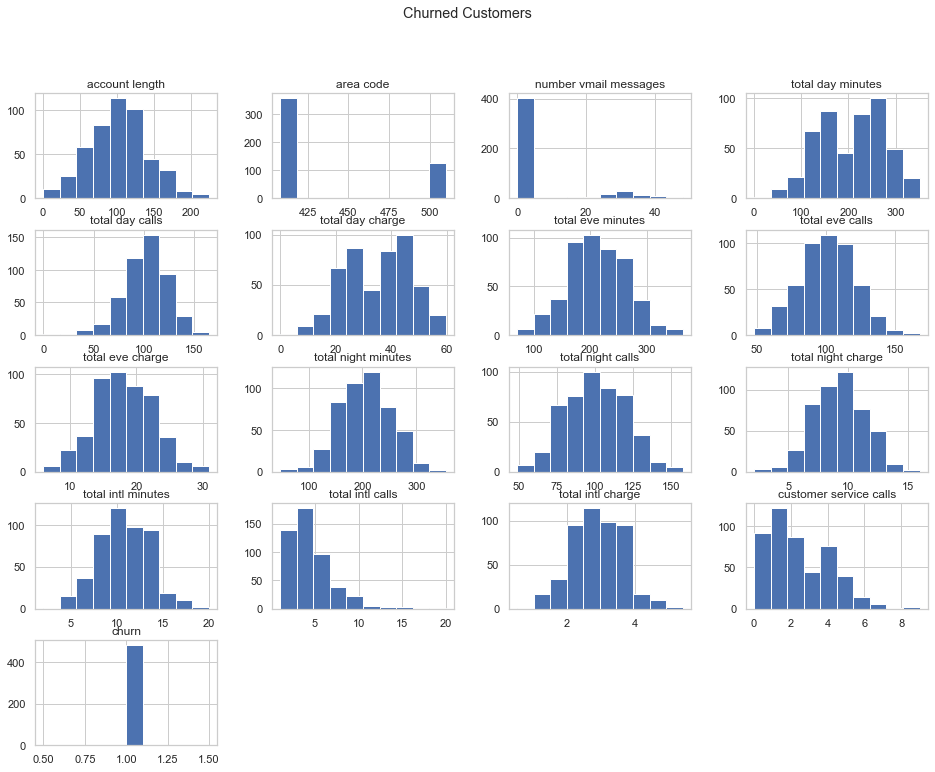

In [75]:
churn_df[churn_df['churn']==0].hist(figsize=(16,12))
plt.suptitle('Non-Churned Customers')
plt.show()

churn_df[churn_df['churn']==1].hist(figsize=(16,12))
plt.suptitle('Churned Customers')
plt.show()

#### **Insights**
1. **Customer Service Calls:**
    - Non-Churned: Concentrated at 0-2 calls(low dissatisfaction).
    - Churned: Spread out to 4-5+ calls, with higher frequency in higher bins.

Customers making frequent service calls are more likely to churn. Target retention for customers with 3+ calls.

---

2. **Total Day/ Evening/ Night Minutes:**
    - Non-churned: Normal distribution centered around 175-180 minutes.
    - Churned: Slightly shifted right (higher usage), with more customers in 200-250 minute range.

High usage might indicate business users or dissatisfaction leading to more calls.

---

3. **Voicemail Messages:**
    - Non-churned: More spread, some with 20-40 messages.
    - Churned: Heavily skewed to 0 messages, very few with voicemail plans.

Churners are less engaged with voicemail features, perhaps they do not value add-ons or are switching to competitors without them.

---

4. **Account Length:**
    - Non-churned: More uniform across 50-200 months.
    - Churned: Slightly more in shorter tenures (under 100 months).

Newer customers churn more, but not dramatically. Loyalty builds over time.

---

#### **Business Takeaway**
Offer perks for high-usage customers (e.g., discounted plans) and proactive support for frequent callers as a retention strategy.

---

### **Correlation Matrix**


The correlation matrix shows relationships between numerical variables.

- Values close to +1 or -1 indicate strong relationships
- Helps identify important features
- Helps detect multicollinearity

This information is useful when selecting features for modeling.

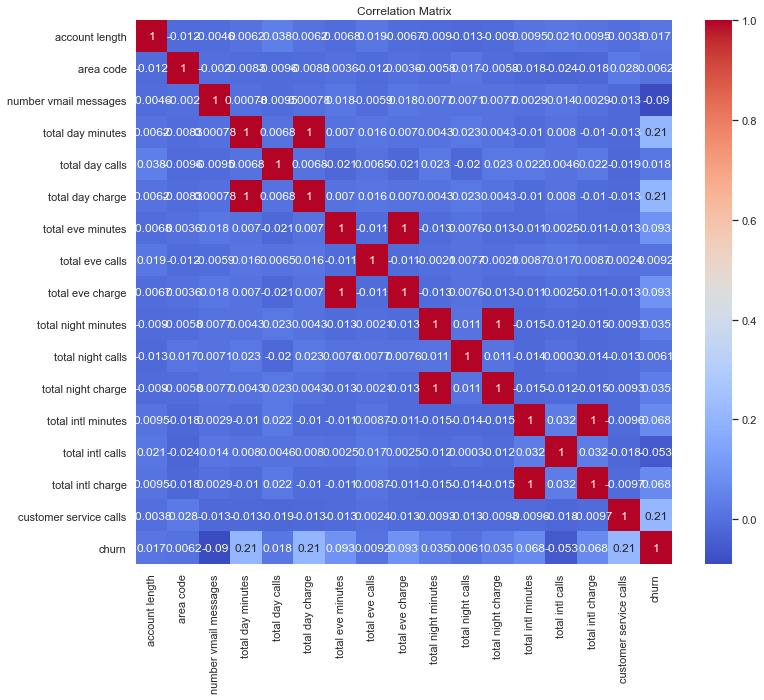

In [65]:
plt.figure(figsize=(12,10))
sns.heatmap(churn_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#### **Insights**
From the correlation matrix above, there is multicollinearity between several features such as;
- total day minutes and total day charge: value= 1
- total eve minutes and total eve charge: value= 1
- total night minutes and total night charge: value= 1
- total intl minutes and total intl charge: value= 1


Multicollinearity between features could affect the model, we deal with it by dropping the features that are highly correlated.

---

### **Categorical Features vs Target Variable 'churn'**

### ***State vs Churn***

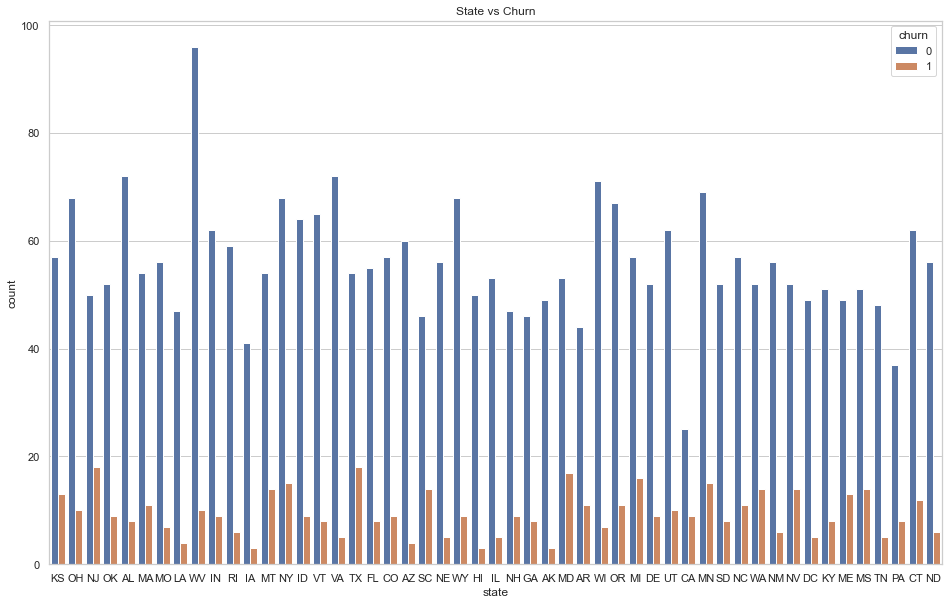

In [66]:
figure, ax = plt.subplots(figsize=(16, 10))
sns.countplot(x='state', hue='churn', data=churn_df)
plt.title("State vs Churn")
plt.show()

#### **Insights**
From the graph above, there is still an imbalance between the retained and churned customers for every state.

States such as NJ, TX, MD and MI have highest number of customers who churned.

In [67]:
# Calculate churn rate for each state

state_churn = churn_df.groupby('state')['churn'].agg(total_customers='count', churned='sum')
state_churn['churn_rate'] = state_churn['churned'] / state_churn['total_customers']
state_churn = state_churn.sort_values('churn_rate', ascending=False)

print(state_churn.head(10))

       total_customers  churned  churn_rate
state                                      
NJ                  68       18    0.264706
CA                  34        9    0.264706
TX                  72       18    0.250000
MD                  70       17    0.242857
SC                  60       14    0.233333
MI                  73       16    0.219178
MS                  65       14    0.215385
NV                  66       14    0.212121
WA                  66       14    0.212121
ME                  62       13    0.209677


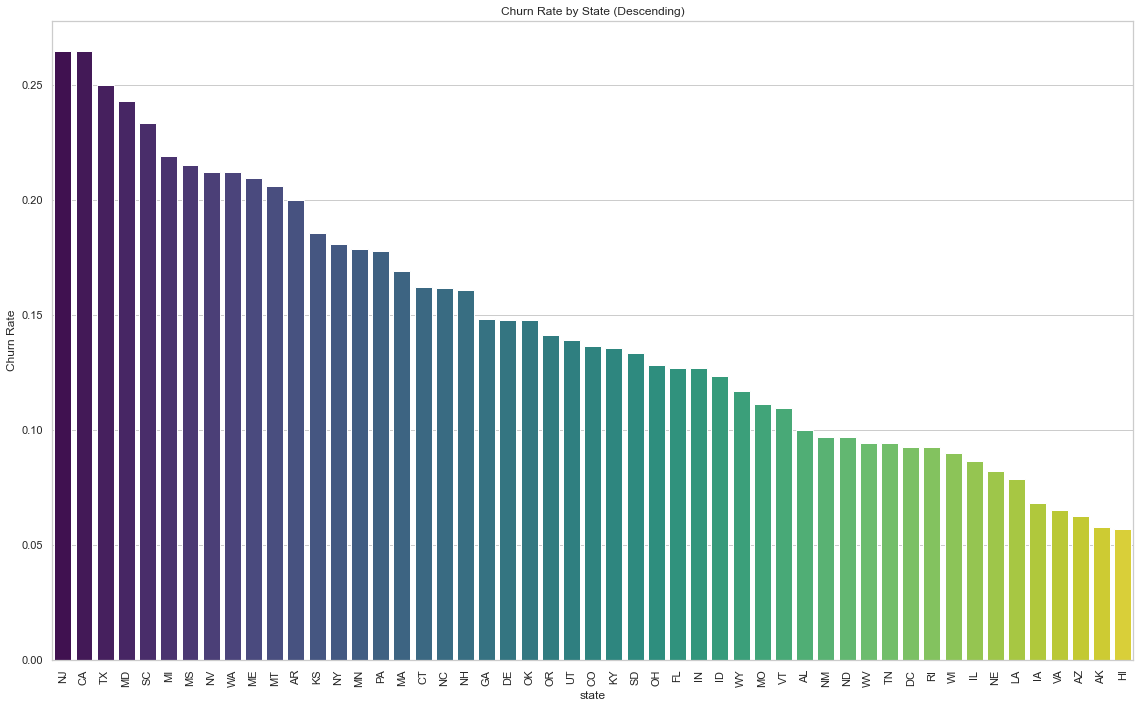

In [68]:
# Visualize churn rate by state

plt.figure(figsize=(16, 10))
sns.barplot(x=state_churn.index, y=state_churn['churn_rate'], palette='viridis')
plt.xticks(rotation=90)
plt.ylabel('Churn Rate')
plt.title('Churn Rate by State (Descending)')
plt.tight_layout()
plt.show()

#### **Insights**
States in the top such as NJ, CA, TX, MD, SC, MI, MS, NV, WA, and ME have the highest proportion of churned customers and are priority for retention action.


---

### ***International Plan vs Churn***

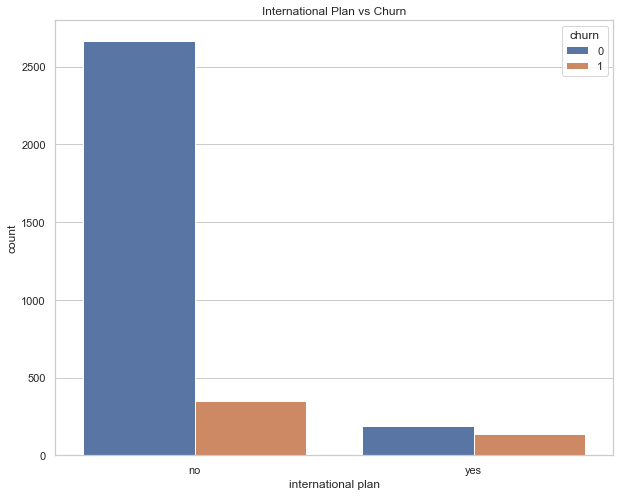

In [76]:
figure, ax = plt.subplots(figsize=(10, 8))
sns.countplot(x='international plan', hue='churn', data=churn_df)
plt.title("International Plan vs Churn")
plt.show()

#### **Insights**
**No international plan (majority):** approximately 2700 customers remained and approximately 300 customers churned. This means that the churn rate for customers with no international plan is approximately 10%.

**Yes international plan (small segment):** approximately 200 retained customers and 150 churned customers. With this the churn rate for customers with an international plan is approximately 43%.

Customers with an international plan are more likely to churn maybe due to higher costs, dissatisfaction or unmet usage needs.

International plan may signal a specific customer segment such as short-term, international travelers or business users.

---

### ***Voice Mail Plan vs Churn***

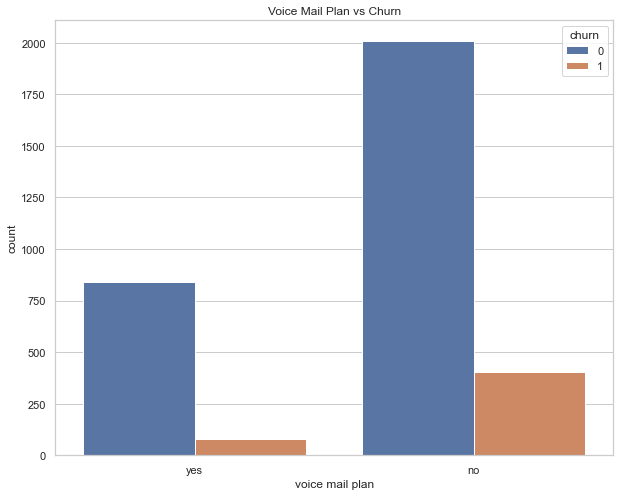

In [77]:
figure, ax = plt.subplots(figsize=(10, 8))
sns.countplot(x='voice mail plan', hue='churn', data=churn_df)
plt.title("Voice Mail Plan vs Churn")
plt.show()

#### **Insights**
Yes (Voicemail plan): approximately 850 retained and 75 churned customers. With this the approximate churn rate for customers with a voicemail plan is 8%.

No (Voicemail plan): approximate 2000 retained and 400 churned customers. The approximate churn rate is 17%.

Customers with a voicemail plan have a significantly lower churn rate.

---

#### **Businees Takeaway**
Promote voicemail plan adoption to new/ at risk customers as a retention strategy. 

Offering free/ discounted voicemail plan could increase adoption.

---